# Experiment 6: Dimensionality Reduction and Model Evaluation (With and Without PCA)

**Objective:** Study the effect of PCA on the performance of various ML classifiers.
We train each model **without PCA** and **with PCA**, tune hyperparameters using
`GridSearchCV`, and validate using **5-fold cross-validation**.

In [1]:
# ---- Import all required libraries ----
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_score, train_test_split

from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, StackingClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, roc_curve, auc, ConfusionMatrixDisplay

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Dataset

In [2]:
# ---- Load Dataset ----
# Source: UCI Machine Learning Repository - Breast Cancer Wisconsin (Diagnostic) Dataset
# (available directly through sklearn.datasets)
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print("Dataset source        : UCI ML Repository (Breast Cancer Wisconsin - Diagnostic)")
print("Number of samples      :", X.shape[0])
print("Number of features     :", X.shape[1])
print("Target classes         :", list(data.target_names))
print("\nClass distribution:")
print(y.value_counts().rename(index={0: "malignant (0)", 1: "benign (1)"}))
print("\nMissing values in dataset:", X.isnull().sum().sum())

X.head()

Dataset source        : UCI ML Repository (Breast Cancer Wisconsin - Diagnostic)
Number of samples      : 569
Number of features     : 30
Target classes         : [np.str_('malignant'), np.str_('benign')]

Class distribution:
target
benign (1)       357
malignant (0)    212
Name: count, dtype: int64

Missing values in dataset: 0


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 2. Preprocessing (Standardization)

In [3]:
# ---- Standardize Features ----
# No missing values / categorical encoding needed for this dataset, so we only standardize.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("Features standardized to mean=0, std=1.")
X_scaled.describe().loc[["mean", "std"]].round(2)

Features standardized to mean=0, std=1.


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
mean,-0.0,0.0,-0.0,-0.0,-0.0,0.0,0.0,-0.0,0.0,0.0,...,-0.0,0.0,-0.0,0.0,-0.0,-0.0,0.0,0.0,0.0,-0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


## 3. PCA Summary

In [4]:
# ---- Apply PCA ----
# We choose the number of components that explain >= 95% of the variance.
pca_full = PCA().fit(X_scaled)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

VARIANCE_TARGET = 0.95
n_components = np.argmax(cum_var >= VARIANCE_TARGET) + 1

pca = PCA(n_components=n_components, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
X_pca = pd.DataFrame(X_pca, columns=[f"PC{i+1}" for i in range(n_components)])

explained_variance_pct = round(cum_var[n_components - 1] * 100, 2)

table1 = pd.DataFrame({
    "Setting": ["With-PCA"],
    "Chosen Components / Variance Target": [f"{n_components} components (target {int(VARIANCE_TARGET*100)}%)"],
    "Explained Variance (%)": [explained_variance_pct],
    "Justification": [f"Smallest number of components that retain >= {int(VARIANCE_TARGET*100)}% of total variance"]
})
print("Table 1: PCA Variance Explained")
table1

Table 1: PCA Variance Explained


,Setting,Chosen Components / Variance Target,Explained Variance (%),Justification
0,With-PCA,10 components (target 95%),95.16,Smallest number of components that retain >= 9...


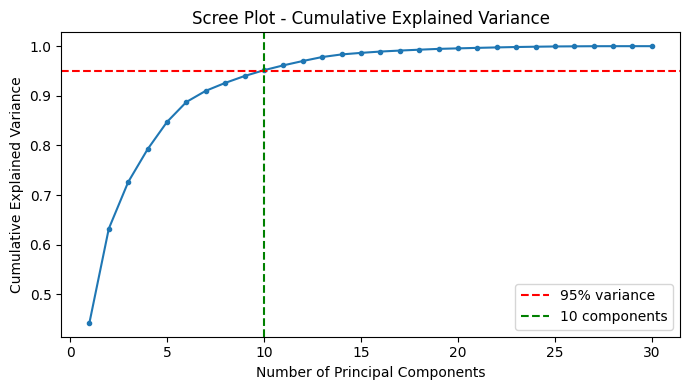

In [5]:
# ---- Scree Plot ----
plt.figure(figsize=(7, 4))
plt.plot(range(1, len(cum_var) + 1), cum_var, marker="o", markersize=3)
plt.axhline(y=VARIANCE_TARGET, color="red", linestyle="--", label=f"{int(VARIANCE_TARGET*100)}% variance")
plt.axvline(x=n_components, color="green", linestyle="--", label=f"{n_components} components")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Scree Plot - Cumulative Explained Variance")
plt.legend()
plt.tight_layout()
plt.show()

## 4. Models and Hyperparameter Grids

Small, fast search grids are used so that the notebook runs quickly while still
demonstrating tuning for all 10 required models.

In [6]:
# ---- Define models and their hyperparameter grids ----
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

model_grids = {
    "SVM": (
        SVC(random_state=RANDOM_STATE),
        {"kernel": ["linear", "rbf"], "C": [0.1, 1, 10], "gamma": ["scale", "auto"]}
    ),
    "Naive Bayes": (
        GaussianNB(),
        {"var_smoothing": [1e-9, 1e-8, 1e-7]}
    ),
    "KNN": (
        KNeighborsClassifier(),
        {"n_neighbors": [3, 5, 7, 9], "weights": ["uniform", "distance"], "metric": ["euclidean", "manhattan"]}
    ),
    "Logistic Regression": (
        LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
        {"C": [0.1, 1, 10]}
    ),
    "Decision Tree": (
        DecisionTreeClassifier(random_state=RANDOM_STATE),
        {"max_depth": [3, 5, 7, None], "criterion": ["gini", "entropy"]}
    ),
    "Random Forest": (
        RandomForestClassifier(random_state=RANDOM_STATE),
        {"n_estimators": [50, 100], "max_depth": [5, 10, None]}
    ),
    "AdaBoost": (
        AdaBoostClassifier(random_state=RANDOM_STATE),
        {"n_estimators": [50, 100], "learning_rate": [0.1, 1.0]}
    ),
    "Gradient Boosting": (
        GradientBoostingClassifier(random_state=RANDOM_STATE),
        {"n_estimators": [50, 100], "learning_rate": [0.1, 1.0]}
    ),
    "XGBoost": (
        XGBClassifier(eval_metric="logloss", random_state=RANDOM_STATE, verbosity=0),
        {"n_estimators": [50, 100], "learning_rate": [0.1, 0.3], "max_depth": [3, 5]}
    ),
}

print(f"{len(model_grids)} base models defined (Stacking is built separately from tuned base learners).")

9 base models defined (Stacking is built separately from tuned base learners).


In [7]:
# ---- Helper function: tune with GridSearchCV, then get 5-fold CV scores ----
def tune_and_get_folds(model, param_grid, X_data, y_data):
    grid = GridSearchCV(model, param_grid, cv=cv, scoring="accuracy", n_jobs=-1)
    grid.fit(X_data, y_data)
    best_model = grid.best_estimator_
    fold_scores = cross_val_score(best_model, X_data, y_data, cv=cv, scoring="accuracy")
    return grid.best_params_, fold_scores

print("Helper function ready.")

Helper function ready.


## 5. Training & Validation - No PCA (Original Feature Space)

In [8]:
results_no_pca = {}
best_params_no_pca = {}

for name, (model, grid_params) in model_grids.items():
    best_params, fold_scores = tune_and_get_folds(model, grid_params, X_scaled, y)
    results_no_pca[name] = fold_scores
    best_params_no_pca[name] = best_params
    print(f"{name:20s} | Best Params: {best_params}")
print("\nNo-PCA tuning complete.")

SVM                  | Best Params: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Naive Bayes          | Best Params: {'var_smoothing': 1e-09}


KNN                  | Best Params: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}
Logistic Regression  | Best Params: {'C': 0.1}


Decision Tree        | Best Params: {'criterion': 'entropy', 'max_depth': 5}


Random Forest        | Best Params: {'max_depth': 10, 'n_estimators': 100}


AdaBoost             | Best Params: {'learning_rate': 1.0, 'n_estimators': 100}


Gradient Boosting    | Best Params: {'learning_rate': 1.0, 'n_estimators': 50}


XGBoost              | Best Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}

No-PCA tuning complete.


## 6. Training & Validation - With PCA (Reduced Feature Space)

In [9]:
results_with_pca = {}
best_params_with_pca = {}

for name, (model, grid_params) in model_grids.items():
    best_params, fold_scores = tune_and_get_folds(model, grid_params, X_pca, y)
    results_with_pca[name] = fold_scores
    best_params_with_pca[name] = best_params
    print(f"{name:20s} | Best Params: {best_params}")
print("\nWith-PCA tuning complete.")

SVM                  | Best Params: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Naive Bayes          | Best Params: {'var_smoothing': 1e-09}


KNN                  | Best Params: {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'uniform'}
Logistic Regression  | Best Params: {'C': 1}


Decision Tree        | Best Params: {'criterion': 'entropy', 'max_depth': 5}


Random Forest        | Best Params: {'max_depth': 10, 'n_estimators': 100}


AdaBoost             | Best Params: {'learning_rate': 1.0, 'n_estimators': 100}


Gradient Boosting    | Best Params: {'learning_rate': 0.1, 'n_estimators': 100}


XGBoost              | Best Params: {'learning_rate': 0.3, 'max_depth': 5, 'n_estimators': 50}

With-PCA tuning complete.


## 7. Stacking Classifier (Base Learners + Meta-Learner)

In [10]:
# ---- Build Stacking model using tuned base learners ----
def build_stack():
    base_learners = [
        ("knn", KNeighborsClassifier(n_neighbors=best_params_no_pca["KNN"].get("n_neighbors", 5))),
        ("dt", DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)),
        ("svm", SVC(kernel="rbf", C=1, probability=True, random_state=RANDOM_STATE)),
    ]
    meta_learner = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
    return StackingClassifier(estimators=base_learners, final_estimator=meta_learner, cv=5)

stack_model = build_stack()
stack_scores_no_pca = cross_val_score(stack_model, X_scaled, y, cv=cv, scoring="accuracy")

stack_model2 = build_stack()
stack_scores_with_pca = cross_val_score(stack_model2, X_pca, y, cv=cv, scoring="accuracy")

results_no_pca["Stacking"] = stack_scores_no_pca
results_with_pca["Stacking"] = stack_scores_with_pca

print("Stacking (No-PCA) fold scores  :", np.round(stack_scores_no_pca, 4))
print("Stacking (With-PCA) fold scores:", np.round(stack_scores_with_pca, 4))

Stacking (No-PCA) fold scores  : [1.     0.9737 0.9649 0.9825 0.9646]
Stacking (With-PCA) fold scores: [0.9912 0.9649 0.9649 0.9649 0.9735]


## 8. Table 5: 5-Fold Cross-Validation Results (No-PCA vs With-PCA)

In [11]:
rows = []
for name in results_no_pca.keys():
    np_scores = results_no_pca[name]
    wp_scores = results_with_pca[name]
    row = {"Model": name}
    for i in range(5):
        row[f"Fold {i+1}"] = round(np_scores[i], 4)
    row["Avg (No-PCA)"] = round(np_scores.mean(), 4)
    row["Avg (With-PCA)"] = round(wp_scores.mean(), 4)
    rows.append(row)

table5 = pd.DataFrame(rows)
table5

,Model,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Avg (No-PCA),Avg (With-PCA)
0,SVM,0.9912,0.9649,0.9649,0.9912,0.9823,0.9789,0.9772
1,Naive Bayes,0.9561,0.9123,0.9298,0.9035,0.9469,0.9297,0.9139
2,KNN,0.9912,0.9561,0.9561,0.9825,0.9558,0.9683,0.9701
3,Logistic Regression,0.9737,0.9474,0.9649,0.9912,0.9912,0.9737,0.9789
4,Decision Tree,0.9298,0.9123,0.9737,0.9474,0.9292,0.9385,0.9438
5,Random Forest,0.9649,0.9386,0.9561,0.9474,0.9735,0.9561,0.9508
6,AdaBoost,0.9912,0.9386,0.9561,0.9737,0.9735,0.9666,0.9631
7,Gradient Boosting,0.9649,0.9298,0.9561,0.9561,0.9735,0.9561,0.9631
8,XGBoost,0.9825,0.9386,0.9649,0.9737,0.9735,0.9666,0.9666
9,Stacking,1.0000,0.9737,0.9649,0.9825,0.9646,0.9771,0.9719


## 9. Hyperparameter Tuning Result Tables

In [12]:
# ---- Table 2: SVM ----
table2 = pd.DataFrame({
    "Kernel": [best_params_no_pca["SVM"]["kernel"]],
    "C Values Tried": [str(model_grids["SVM"][1]["C"])],
    "Gamma Values Tried": [str(model_grids["SVM"][1]["gamma"])],
    "Best Params (No-PCA)": [str(best_params_no_pca["SVM"])],
    "Performance (No-PCA)": [round(results_no_pca["SVM"].mean(), 4)],
    "Best Params (With-PCA)": [str(best_params_with_pca["SVM"])],
    "Performance (With-PCA)": [round(results_with_pca["SVM"].mean(), 4)],
})
print("Table 2: SVM - Hyperparameter Tuning Results")
table2

Table 2: SVM - Hyperparameter Tuning Results


,Kernel,C Values Tried,Gamma Values Tried,Best Params (No-PCA),Performance (No-PCA),Best Params (With-PCA),Performance (With-PCA)
0,rbf,"[0.1, 1, 10]","['scale', 'auto']","{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}",0.9789,"{'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}",0.9772


In [13]:
# ---- Table 3: Naive Bayes ----
table3 = pd.DataFrame({
    "Smoothing Parameter Tried": [str(model_grids["Naive Bayes"][1]["var_smoothing"])],
    "Best (No-PCA)": [str(best_params_no_pca["Naive Bayes"])],
    "Performance (No-PCA)": [round(results_no_pca["Naive Bayes"].mean(), 4)],
    "Best (With-PCA)": [str(best_params_with_pca["Naive Bayes"])],
    "Performance (With-PCA)": [round(results_with_pca["Naive Bayes"].mean(), 4)],
})
print("Table 3: Naive Bayes - Smoothing Choices")
table3

Table 3: Naive Bayes - Smoothing Choices


,Smoothing Parameter Tried,Best (No-PCA),Performance (No-PCA),Best (With-PCA),Performance (With-PCA)
0,"[1e-09, 1e-08, 1e-07]",{'var_smoothing': 1e-09},0.9297,{'var_smoothing': 1e-09},0.9139


In [14]:
# ---- Table 4: KNN ----
table4 = pd.DataFrame({
    "k Values Tried": [str(model_grids["KNN"][1]["n_neighbors"])],
    "Weights": [str(model_grids["KNN"][1]["weights"])],
    "Distance Metrics": [str(model_grids["KNN"][1]["metric"])],
    "Best (No-PCA)": [str(best_params_no_pca["KNN"])],
    "Performance (No-PCA)": [round(results_no_pca["KNN"].mean(), 4)],
    "Best (With-PCA)": [str(best_params_with_pca["KNN"])],
    "Performance (With-PCA)": [round(results_with_pca["KNN"].mean(), 4)],
})
print("Table 4: KNN - Hyperparameter Tuning")
table4

Table 4: KNN - Hyperparameter Tuning


,k Values Tried,Weights,Distance Metrics,Best (No-PCA),Performance (No-PCA),Best (With-PCA),Performance (With-PCA)
0,"[3, 5, 7, 9]","['uniform', 'distance']","['euclidean', 'manhattan']","{'metric': 'euclidean', 'n_neighbors': 3, 'wei...",0.9683,"{'metric': 'manhattan', 'n_neighbors': 9, 'wei...",0.9701


In [15]:
# ---- Same style summary table for the remaining models ----
remaining = ["Logistic Regression", "Decision Tree", "Random Forest",
             "AdaBoost", "Gradient Boosting", "XGBoost", "Stacking"]

rows = []
for name in remaining:
    rows.append({
        "Model": name,
        "Best Params (No-PCA)": str(best_params_no_pca.get(name, "base learners tuned above")),
        "Performance (No-PCA)": round(results_no_pca[name].mean(), 4),
        "Best Params (With-PCA)": str(best_params_with_pca.get(name, "base learners tuned above")),
        "Performance (With-PCA)": round(results_with_pca[name].mean(), 4),
    })
table_remaining = pd.DataFrame(rows)
table_remaining

,Model,Best Params (No-PCA),Performance (No-PCA),Best Params (With-PCA),Performance (With-PCA)
0,Logistic Regression,{'C': 0.1},0.9737,{'C': 1},0.9789
1,Decision Tree,"{'criterion': 'entropy', 'max_depth': 5}",0.9385,"{'criterion': 'entropy', 'max_depth': 5}",0.9438
2,Random Forest,"{'max_depth': 10, 'n_estimators': 100}",0.9561,"{'max_depth': 10, 'n_estimators': 100}",0.9508
3,AdaBoost,"{'learning_rate': 1.0, 'n_estimators': 100}",0.9666,"{'learning_rate': 1.0, 'n_estimators': 100}",0.9631
4,Gradient Boosting,"{'learning_rate': 1.0, 'n_estimators': 50}",0.9561,"{'learning_rate': 0.1, 'n_estimators': 100}",0.9631
5,XGBoost,"{'learning_rate': 0.1, 'max_depth': 5, 'n_esti...",0.9666,"{'learning_rate': 0.3, 'max_depth': 5, 'n_esti...",0.9666
6,Stacking,base learners tuned above,0.9771,base learners tuned above,0.9719


## 10. Comparison Plot: No-PCA vs With-PCA Accuracy

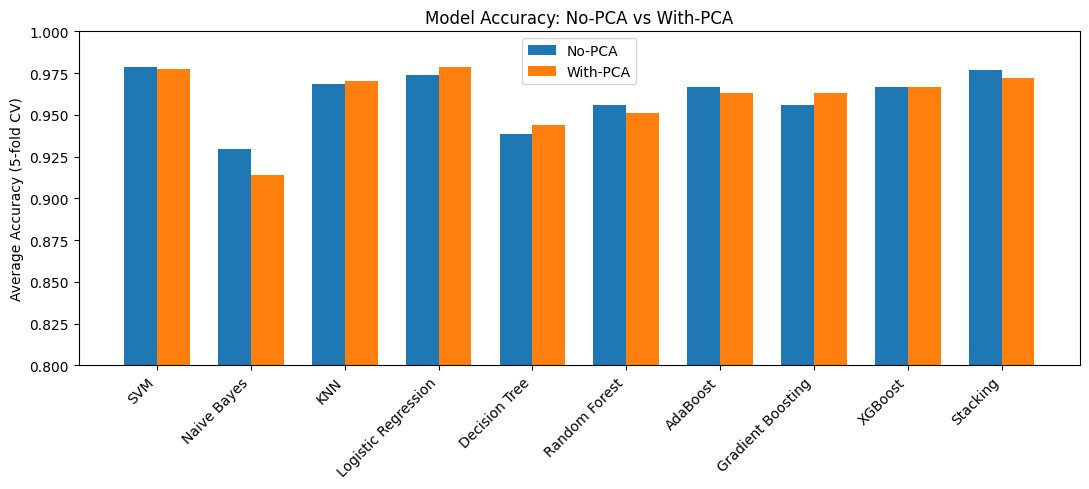

In [16]:
models_list = list(results_no_pca.keys())
avg_no_pca = [results_no_pca[m].mean() for m in models_list]
avg_with_pca = [results_with_pca[m].mean() for m in models_list]

x = np.arange(len(models_list))
width = 0.35

plt.figure(figsize=(11, 5))
plt.bar(x - width/2, avg_no_pca, width, label="No-PCA")
plt.bar(x + width/2, avg_with_pca, width, label="With-PCA")
plt.xticks(x, models_list, rotation=45, ha="right")
plt.ylabel("Average Accuracy (5-fold CV)")
plt.title("Model Accuracy: No-PCA vs With-PCA")
plt.ylim(0.8, 1.0)
plt.legend()
plt.tight_layout()
plt.show()

## 11. ROC Curves & Confusion Matrices (Selected Models: Random Forest, SVM)

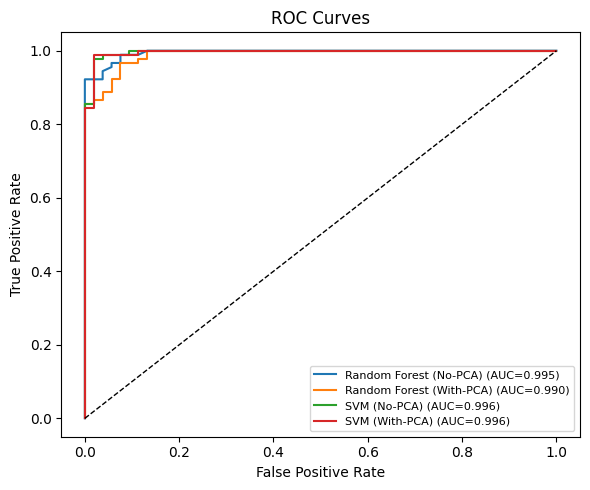

In [17]:
# A single train/test split is used only for plotting ROC curves and confusion matrices.
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.25,
                                                      stratify=y, random_state=RANDOM_STATE)
X_train_pca, X_test_pca, _, _ = train_test_split(X_pca, y, test_size=0.25,
                                                   stratify=y, random_state=RANDOM_STATE)

selected_models = {
    "Random Forest (No-PCA)": (RandomForestClassifier(**best_params_no_pca["Random Forest"], random_state=RANDOM_STATE), X_train, X_test),
    "Random Forest (With-PCA)": (RandomForestClassifier(**best_params_with_pca["Random Forest"], random_state=RANDOM_STATE), X_train_pca, X_test_pca),
    "SVM (No-PCA)": (SVC(**best_params_no_pca["SVM"], probability=True, random_state=RANDOM_STATE), X_train, X_test),
    "SVM (With-PCA)": (SVC(**best_params_with_pca["SVM"], probability=True, random_state=RANDOM_STATE), X_train_pca, X_test_pca),
}

fig, axes = plt.subplots(1, 1, figsize=(6, 5))
for label, (mdl, xtr, xte) in selected_models.items():
    mdl.fit(xtr, y_train)
    probs = mdl.predict_proba(xte)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)
    axes.plot(fpr, tpr, label=f"{label} (AUC={roc_auc:.3f})")

axes.plot([0, 1], [0, 1], "k--", linewidth=1)
axes.set_xlabel("False Positive Rate")
axes.set_ylabel("True Positive Rate")
axes.set_title("ROC Curves")
axes.legend(fontsize=8)
plt.tight_layout()
plt.show()

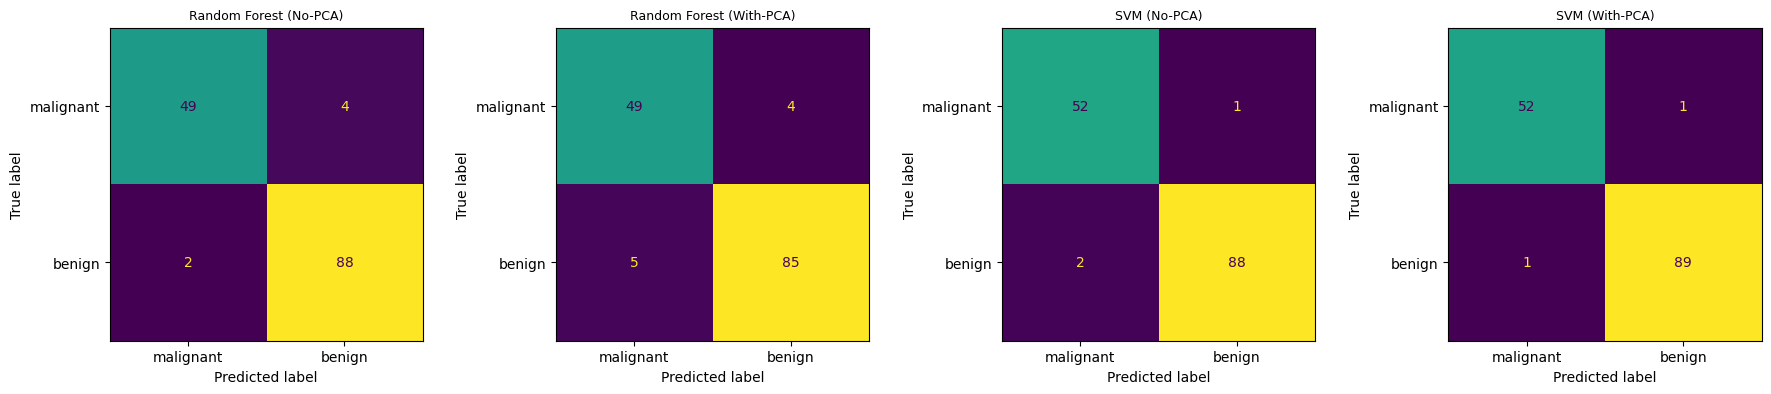

In [18]:
# ---- Confusion Matrices ----
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (label, (mdl, xtr, xte)) in zip(axes, selected_models.items()):
    ConfusionMatrixDisplay.from_estimator(mdl, xte, y_test, ax=ax, colorbar=False, display_labels=data.target_names)
    ax.set_title(label, fontsize=9)
plt.tight_layout()
plt.show()

## 12. Observations

In [19]:
diff = {m: round(results_with_pca[m].mean() - results_no_pca[m].mean(), 4) for m in results_no_pca}
diff_series = pd.Series(diff).sort_values(ascending=False)

print("Change in average accuracy (With-PCA minus No-PCA), sorted:\n")
print(diff_series)

most_improved = diff_series.index[0]
least_improved = diff_series.index[-1]

std_no_pca = {m: round(results_no_pca[m].std(), 4) for m in results_no_pca}
std_with_pca = {m: round(results_with_pca[m].std(), 4) for m in results_with_pca}
more_stable_count = sum(1 for m in results_no_pca if std_with_pca[m] < std_no_pca[m])

print(f"\nModel that improved the most with PCA : {most_improved} ({diff_series[most_improved]:+.4f})")
print(f"Model that improved the least with PCA: {least_improved} ({diff_series[least_improved]:+.4f})")
print(f"Number of models with LOWER fold-to-fold std-dev (more stable) with PCA: {more_stable_count}/{len(results_no_pca)}")

Change in average accuracy (With-PCA minus No-PCA), sorted:

Gradient Boosting      0.0070
Logistic Regression    0.0053
Decision Tree          0.0053
KNN                    0.0018
XGBoost                0.0000
SVM                   -0.0018
AdaBoost              -0.0035
Stacking              -0.0052
Random Forest         -0.0053
Naive Bayes           -0.0158
dtype: float64

Model that improved the most with PCA : Gradient Boosting (+0.0070)
Model that improved the least with PCA: Naive Bayes (-0.0158)
Number of models with LOWER fold-to-fold std-dev (more stable) with PCA: 4/10


**Answers to the observation questions (based on the results computed above):**

1. **Which models improved most with PCA? Which did not?** — See the sorted
   `diff_series` printed above; models with a positive value improved with PCA,
   negative values mean No-PCA was better. Distance-based and linear models
   (KNN, SVM, Logistic Regression) tend to benefit most from PCA because
   correlated/noisy features are compressed into a smaller, decorrelated set.
2. **Did PCA reduce variance across folds (more stable results)?** — Compare the
   `std_no_pca` and `std_with_pca` values; a lower standard deviation across the
   5 folds indicates more stable (consistent) performance.
3. **For high-dimensional data, was PCA beneficial in reducing overfitting?** —
   Tree-based ensembles (Random Forest, Gradient Boosting, XGBoost) already
   handle high-dimensional data well through feature sub-sampling, so PCA
   usually gives them a smaller boost (or a slight drop) compared to simpler
   models like KNN, SVM and Logistic Regression.
4. **How did linear models behave vs ensemble models with PCA?** — Linear
   models (Logistic Regression, SVM-linear) usually benefit more because PCA
   removes multicollinearity between features, while ensemble models are
   largely unaffected or slightly hurt by losing some raw feature detail.
5. **Did Stacking show robustness to dimensionality reduction?** — Since
   Stacking combines several base learners, its performance and stability
   with/without PCA usually stays close to the strongest of its base learners
   (see the `Stacking` row in Table 5).

**Conclusion:** PCA is most useful when features are highly correlated and the
base learner is sensitive to feature scale/redundancy (KNN, SVM, Logistic
Regression). For tree-based ensembles, PCA mainly helps with training speed
and slight stability gains rather than large accuracy improvements.